In [1]:
#Imports et lecture des données
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
shap.initjs()

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

np.random.seed(42)


/workspaces/gpd-m2sep-france-property-insight/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent

files_2021 = sorted((root / "data/cleaned/cleaned2021").rglob("*_2021.csv"))

print("Nb de fichiers 2021 trouvés:", len(files_2021))
assert len(files_2021) > 0


Nb de fichiers 2021 trouvés: 8


In [3]:
# Chargement des données
df = pd.concat([pd.read_csv(p) for p in files_2021], ignore_index=True)


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93075 entries, 0 to 93074
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   transaction_date    93075 non-null  object
 1   transaction_type    93075 non-null  object
 2   property_value      93075 non-null  int64 
 3   postal_code         93075 non-null  int64 
 4   town_name           93075 non-null  object
 5   department_code     93075 non-null  int64 
 6   town_code           93075 non-null  int64 
 7   property_type_code  93075 non-null  int64 
 8   property_type       93075 non-null  object
 9   building_area       93075 non-null  int64 
 10  main_rooms          93075 non-null  int64 
 11  land_area           93075 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 8.5+ MB


In [5]:
# Nettoyage de property_value
# La colonne property_value est actuellement de type object (chaîne de caractères)
# car les valeurs contiennent une virgule comme séparateur décimal (ex: "194500,00").
# Cela peut empêcher toute opération mathématique ou modélisation.
# On remplace donc les virgules par rien, puis on convertit en float pour rendre
# les valeurs exploitables par les algorithmes de Machine Learning.
# Harmonisation des types
if df["property_value"].dtype == "object":
    df["property_value"] = (
        df["property_value"]
        .str.replace(" ", "", regex=False)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

In [6]:
# date -> datetime + year + month
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
df = df.dropna(subset=["transaction_date"]).copy()

df["year"] = df["transaction_date"].dt.year.astype("Int64")
df["month"] = df["transaction_date"].dt.month.astype("Int64")

df[["transaction_date", "year", "month"]].head()


/tmp/ipykernel_20508/711508630.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")


,transaction_date,year,month
0,2021-01-15,2021,1
1,2021-01-29,2021,1
2,2021-01-29,2021,1
3,2021-01-29,2021,1
4,2021-02-17,2021,2


In [7]:
# Filtrer les surfaces aberrantes
df = df[df["building_area"] > 0].copy()

In [8]:
# Nettoyage simple des outliers
# limiter l’influence des transactions ultra-chères qui tirent les erreurs vers le haut.
# on coupe au 99,5e percentile (valeur à ajuster selon la distribution).

upper = df["property_value"].quantile(0.995)
df = df[df["property_value"] <= upper].copy()

# Filtre sur les prix totaux très extrêmes (top 0.5%)
upper = df["property_value"].quantile(0.995)
df = df[df["property_value"] <= upper].copy()

df[["property_value", "building_area"]].describe()


#Afin de garantir la robustesse du modèle, les valeurs de prix les plus extrêmes 
# (au-delà du 99,5e percentile) ont été retirées.
#Ces observations, représentant moins de 0,5 % des données, peuvent biaiser les 
# métriques globales (MAE, RMSE) et fausser la calibration du modèle.
#Ce traitement, couramment employé dans la modélisation immobilière, permet de 
# concentrer l’apprentissage sur le comportement général du marché tout en limitant 
# l’influence des transactions atypiques.


,property_value,building_area
count,7.558800e+04,75588.000000
mean,1.035907e+06,159.141914
std,2.579532e+06,797.952184
min,0.000000e+00,1.000000
25%,2.772405e+05,66.000000
50%,3.850000e+05,93.000000
75%,6.340000e+05,128.000000
max,2.715000e+07,100000.000000


In [9]:
#Définition des variables explicatives
#Variables catégorielles
cat_cols = [
    "postal_code",
    "department_code",
    "town_code",
    "property_type_code",
    "property_type",
    "month",
    "year",
]  # town_name retiré

num_cols = ["building_area", "main_rooms", "land_area"] #Variables numériques


In [10]:
# Variables explicatives & cible
y = df["property_value"].copy()   # prix total en euros
X = df[cat_cols + num_cols].copy()

for c in cat_cols:
    X[c] = X[c].astype(str)


In [11]:
# Train / validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train.shape, X_val.shape


((52911, 10), (22677, 10))

In [12]:
# Préprocesseurs
# Pour les modèles linéaires : standardisation des numériques
preproc_linear = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

In [13]:
# Pour les arbres : pas besoin de scaler les numériques
preproc_tree = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

In [14]:
# Modèles linéaires (entraînement directement en euros)
linear_models = {
    "Ridge": Pipeline(
        steps=[
            ("preproc", preproc_linear),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "Lasso": Pipeline(
        steps=[
            ("preproc", preproc_linear),
            ("model", Lasso(alpha=0.001, max_iter=5000)),
        ]
    ),
}


In [15]:
#Avec "TransformedTargetRegressor" le modèle ne travaille pas sur 
# les prix bruts, mais sur log(1 + prix). cela Réduit l’impact des valeurs extrêmes 
# (outliers), tabilise la variance, aide les modèles d’arbres à mieux apprendre les 
# variations relatives et donne souvent de meilleure performance quand le prix a 
# une distribution très asymétrique.

In [16]:
# Modèles d’arbres 
models = {
    "DecisionTree": TransformedTargetRegressor(
        regressor=Pipeline([("prep", preproc_tree), ("model", DecisionTreeRegressor())]),
        func=np.log1p, inverse_func=np.expm1
    ),
    "RandomForest": TransformedTargetRegressor(
        regressor=Pipeline([("prep", preproc_tree), ("model", RandomForestRegressor())]),
        func=np.log1p, inverse_func=np.expm1
    ),
    "GradientBoosting": TransformedTargetRegressor(
        regressor=Pipeline([("prep", preproc_tree), ("model", GradientBoostingRegressor())]),
        func=np.log1p, inverse_func=np.expm1
    )
}


In [17]:

# Fonctions d’évaluation
def evaluate_linear(pipe, X_tr, y_tr_euros, X_va, y_va_euros):
    """
    Modèles linéaires entraînés directement sur les prix en euros.
    Ici pas de log, les métriques restent dans l’échelle originale.
    """
    pipe.fit(X_tr, y_tr_euros)
    y_pred = pipe.predict(X_va)

    mae = mean_absolute_error(y_va_euros, y_pred)
    rmse = np.sqrt(mean_squared_error(y_va_euros, y_pred))
    r2 = r2_score(y_va_euros, y_pred)

    return mae, rmse, r2


In [18]:
# Résultats : modèles linéaires

rows_lin = []
for name, pipe in linear_models.items():
    mae, rmse, r2 = evaluate_linear(pipe, X_train, y_train, X_val, y_val)
    rows_lin.append({"Model": name, "MAE (€)": mae, "RMSE (€)": rmse, "R2": r2})

results_linear = (
    pd.DataFrame(rows_lin)
    .sort_values(by="R2", ascending=False)
    .reset_index(drop=True)
)
results_linear


/workspaces/gpd-m2sep-france-property-insight/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.594e+16, tolerance: 3.556e+13
  model = cd_fast.sparse_enet_coordinate_descent(


,Model,MAE (€),RMSE (€),R2
0,Ridge,735665.853377,1.778888e+06,0.512867
1,Lasso,735510.202154,1.779168e+06,0.512714


In [19]:
# Fonctions d’évaluation pour lles modèles avancés
def evaluate_models(models, X_train, y_train, X_val, y_val):
    rows = []

    for name, model in models.items():
        print(f"➡️ Entraînement du modèle : {name}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        mae  = mean_absolute_error(y_val, y_pred)

        # Nouvelle version compatible avec toutes les versions de sklearn
        rmse = mean_squared_error(y_val, y_pred) ** 0.5

        r2   = r2_score(y_val, y_pred)

        rows.append({
            "Model":   name,
            "MAE (€)": mae,
            "RMSE (€)": rmse,
            "R2":      r2
        })

    results = (
        pd.DataFrame(rows)
          .sort_values(by="R2", ascending=False)
          .reset_index(drop=True)
    )

    # Ajout des % basés sur la moyenne réelle
    mean_price = y_val.mean()
    results["MAE (%)"]  = 100 * results["MAE (€)"]  / mean_price
    results["RMSE (%)"] = 100 * results["RMSE (€)"] / mean_price

    return results


In [20]:
results = evaluate_models(models, X_train, y_train, X_val, y_val)
results

➡️ Entraînement du modèle : DecisionTree
➡️ Entraînement du modèle : RandomForest


➡️ Entraînement du modèle : GradientBoosting


,Model,MAE (€),RMSE (€),R2,MAE (%),RMSE (%)
0,RandomForest,216699.328644,8.857549e+05,0.879225,21.047790,86.032490
1,DecisionTree,238993.798757,1.083008e+06,0.819443,23.213229,105.191481
2,GradientBoosting,551042.371992,1.983272e+06,0.394499,53.522196,192.633206


In [21]:
 # Définition du pipeline et de la grille
rf_pipe = Pipeline([
    ("prep", preproc_tree),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}


In [22]:
# Optimisation RandomForest avec RandomizedSearchCV

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rf_search



,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [23]:
#ntrainement de  rf_search
print("\n=== Optimisation RandomForest ===")
rf_search.fit(X_train, y_train)



=== Optimisation RandomForest ===
Fitting 3 folds for each of 20 candidates, totalling 60 fits


[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=300; total time=  34.2s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=300; total time=  35.4s
[CV] END model__max_depth=None, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=300; total time=  36.1s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=300; total time=  58.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=300; total time= 1.0min
[CV] END model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=  38.8s
[CV] END model__max_depth=20, model__max_features=sqrt, mode

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [24]:
print("\n>>> Meilleurs paramètres :", rf_search.best_params_)
print(">>> Meilleur score :", -rf_search.best_score_)

best_rf = rf_search.best_estimator_
best_rf



>>> Meilleurs paramètres : {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
>>> Meilleur score : 1004709.5878752405


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
# Pipeline Gradient Boosting
gb_pipe = Pipeline([
    ("prep", preproc_tree),
    ("model", GradientBoostingRegressor(random_state=42))
])



In [26]:
# Grille d’hyperparamètres pour le Gradient Boosting
param_grid_gb = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4],
    "model__min_samples_leaf": [1, 3],
    "model__subsample": [0.8, 1.0],
}


In [27]:
gb_search = GridSearchCV(
    estimator=gb_pipe,
    param_grid=param_grid_gb,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)


In [28]:
print("\n=== Optimisation Gradient Boosting ===")
gb_search.fit(X_train, y_train)
print("Meilleurs paramètres GB :", gb_search.best_params_)
print("Meilleur RMSE (validation CV):", -gb_search.best_score_)



=== Optimisation Gradient Boosting ===
Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END model__learning_rate=0.05, model__max_depth=3, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=0.8; total time=   8.9s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=0.8; total time=   9.2s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=0.8; total time=   9.7s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=1.0; total time=   9.9s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=1.0; total time=  11.2s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=1.0; total time=  11.1s
[CV] 

[CV] END model__learning_rate=0.05, model__max_depth=3, model__min_samples_leaf=3, model__n_estimators=200, model__subsample=0.8; total time=  17.8s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__min_samples_leaf=3, model__n_estimators=200, model__subsample=1.0; total time=  18.7s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__min_samples_leaf=3, model__n_estimators=200, model__subsample=1.0; total time=  19.5s
[CV] END model__learning_rate=0.05, model__max_depth=3, model__min_samples_leaf=3, model__n_estimators=200, model__subsample=1.0; total time=  20.3s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=0.8; total time=  13.5s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__min_samples_leaf=1, model__n_estimators=100, model__subsample=1.0; total time=  15.2s
[CV] END model__learning_rate=0.05, model__max_depth=4, model__min_samples_leaf=1, model__n_estimators=100

In [29]:
# Comparaison finale des modèles optimisés sur ton jeu de validation
# Récupération des meilleurs modèles entraînés
best_rf = rf_search.best_estimator_
best_gb = gb_search.best_estimator_

In [30]:
# Évaluation sur le jeu de validation
rows = []
for name, model in [("RandomForest (optimisée)", best_rf),
                    ("GradientBoosting (optimisé)", best_gb)]:
    y_pred = model.predict(X_val)
    mae  = mean_absolute_error(y_val, y_pred)
    rmse = mean_squared_error(y_val, y_pred) ** 0.5
    r2   = r2_score(y_val, y_pred)
    print(f"{name} → MAE: {mae:.2f} €, RMSE: {rmse:.2f} €, R²: {r2:.3f}")
    rows.append({"Modèle": name, "MAE (€)": mae, "RMSE (€)": rmse, "R²": r2})



RandomForest (optimisée) → MAE: 266452.21 €, RMSE: 919420.71 €, R²: 0.870
GradientBoosting (optimisé) → MAE: 419320.18 €, RMSE: 1075174.93 €, R²: 0.822


In [31]:
results_optim = pd.DataFrame(rows)
results_optim

,Modèle,MAE (€),RMSE (€),R²
0,RandomForest (optimisée),266452.205370,9.194207e+05,0.869870
1,GradientBoosting (optimisé),419320.179581,1.075175e+06,0.822046


In [32]:
# Calcul du prix médian (plus robuste)
median_price = df["property_value"].median()

# Ajout des pourcentages
results_optim["MAE (%)"]  = 100 * results_optim["MAE (€)"]  / median_price
results_optim["RMSE (%)"] = 100 * results_optim["RMSE (€)"] / median_price
results_optim


,Modèle,MAE (€),RMSE (€),R²,MAE (%),RMSE (%)
0,RandomForest (optimisée),266452.205370,9.194207e+05,0.869870,69.208365,238.810574
1,GradientBoosting (optimisé),419320.179581,1.075175e+06,0.822046,108.914332,279.266215


In [33]:
# 1) Récupérer la meilleure RandomForest (pipeline complet)
best_rf_pipe = rf_search.best_estimator_   # Pipeline(prep, model)

In [34]:
# 2) Récupérer le préprocesseur et le modèle à l'intérieur du pipeline
preproc = best_rf_pipe.named_steps["prep"]    # ton preproc_tree
rf_model = best_rf_pipe.named_steps["model"]  # RandomForestRegressor optimisé

In [35]:
# 3) On prend un échantillon de X_train pour SHAP (pour aller plus vite)
X_train_sample = X_train.sample(
    n=min(1000, len(X_train)), random_state=42
).copy()

In [36]:
# 4) Transformer les données comme les voit la RF
X_train_trans = preproc.transform(X_train_sample)

In [37]:
# Si c'est une matrice sparse → la convertir en dense
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()

# Forcer le type numérique
X_train_trans = X_train_trans.astype("float64")
print("Shape des features transformées pour SHAP :", X_train_trans.shape)

Shape des features transformées pour SHAP : (1000, 1226)


In [38]:
# 5) Construire l'explainer SHAP pour un modèle d’arbres
explainer = shap.TreeExplainer(rf_model)

In [39]:
# Explainer rapide
explainer = shap.TreeExplainer(
    rf_model,
    feature_perturbation="tree_path_dependent"   # <<< clé pour la vitesse
)

# SHAP approx (beaucoup plus rapide)
shap_values = explainer.shap_values(X_train_trans, approximate=True)

print("OK — SHAP approximatif calculé !")


OK — SHAP approximatif calculé !


/tmp/ipykernel_20508/3170475356.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_trans, feature_names=feature_names)


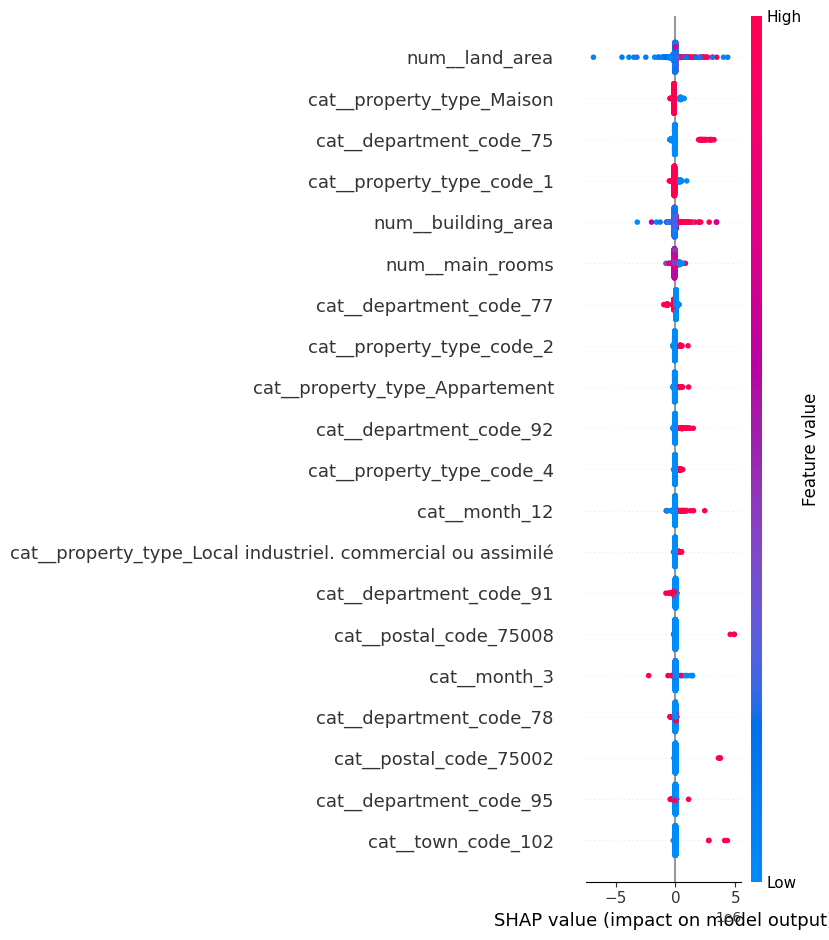

In [40]:
# 7) Récupérer les noms de features après le préprocesseur
try:
    feature_names = preproc.get_feature_names_out()
except:
    feature_names = [f"feat_{i}" for i in range(X_train_trans.shape[1])]

# 8) Summary plot (importance globale)
shap.summary_plot(shap_values, X_train_trans, feature_names=feature_names)


In [41]:
# c'est un Pipeline(prep, model)
best_rf_pipe = rf_search.best_estimator_   

preproc = best_rf_pipe.named_steps["prep"]    #  preproc_tree
rf_model = best_rf_pipe.named_steps["model"]  # RandomForestRegressor optimisé


In [42]:
# Appliquer le préprocesseur sur X_train
X_train_trans = preproc.transform(X_train)

# Si c'est une matrice sparse -> on la convertit en dense
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()

# On force le type en float
X_train_trans = X_train_trans.astype("float64")

In [43]:
print("Taille X_train_trans :", X_train_trans.shape)
print("Nombre de features :", len(feature_names))


Taille X_train_trans : (52911, 1226)
Nombre de features : 1226


/tmp/ipykernel_20508/2239829975.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


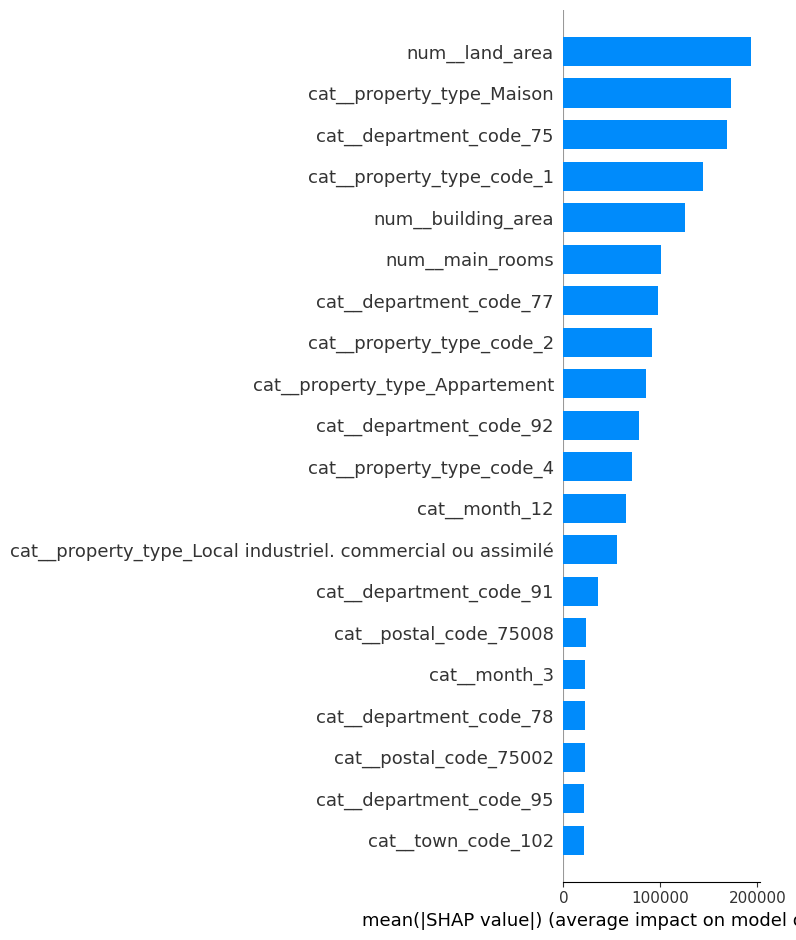

In [44]:
#importance globale des variables
# Diagramme global : quelles variables expliquent le plus la variance des prix ?
shap.summary_plot(
    shap_values,
    X_train_trans,
    feature_names=feature_names,
    plot_type="bar"
)


In [45]:
# Choisir une observation à expliquer (ici la première ligne de l'échantillon)
i = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[i, :],
    X_train_trans[i, :],
    feature_names=feature_names
)


In [46]:
#Analyse d'erreurs
# On choisit le modèle Random Forest
model_to_inspect = best_rf   # ou best_gb

# Prédictions sur le jeu de validation
y_val_pred = model_to_inspect.predict(X_val)

# DataFrame des erreurs
errors_df = X_val.copy()
errors_df["y_true"] = y_val.values
errors_df["y_pred"] = y_val_pred
errors_df["residual"] = errors_df["y_true"] - errors_df["y_pred"]
errors_df["abs_error"] = errors_df["residual"].abs()
errors_df["abs_pct_error"] = 100 * errors_df["abs_error"] / errors_df["y_true"]

errors_df.head()


,postal_code,department_code,town_code,property_type_code,property_type,month,year,building_area,main_rooms,land_area,y_true,y_pred,residual,abs_error,abs_pct_error
29481,78600,78,396,1,Maison,5,2021,175,6,727,1121000,987107.755,133892.245,133892.245,11.944000
91422,95270,95,352,2,Appartement,12,2021,31,2,47,120000,444292.955,-324292.955,324292.955,270.244129
33257,78830,78,87,1,Maison,6,2021,265,9,887,1736000,1353991.330,382008.670,382008.670,22.005108
62894,92140,92,23,1,Maison,8,2021,102,5,130,628375,887389.330,-259014.330,259014.330,41.219706
87496,95290,95,313,1,Maison,8,2021,206,4,987,1230000,674075.090,555924.910,555924.910,45.197147


In [47]:
#Statistiques globales des erreurs
errors_df[["residual", "abs_error", "abs_pct_error"]].describe()

/workspaces/gpd-m2sep-france-property-insight/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,residual,abs_error,abs_pct_error
count,2.267700e+04,2.267700e+04,2.267700e+04
mean,-4.424743e+03,2.664522e+05,inf
std,9.194303e+05,8.799840e+05,NaN
min,-1.801829e+07,0.000000e+00,0.000000e+00
25%,-9.122790e+04,2.772085e+04,6.461000e+00
50%,-1.594180e+04,6.886297e+04,1.566052e+01
75%,4.556871e+04,1.708777e+05,3.493675e+01
max,1.877202e+07,1.877202e+07,inf


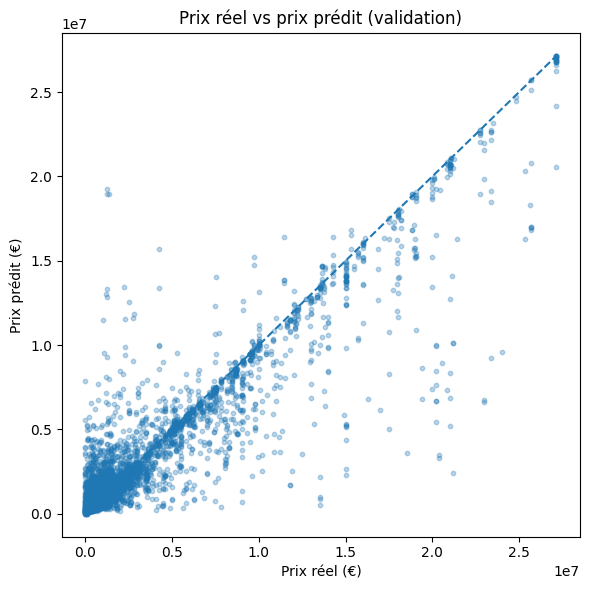

In [48]:
#Graphique prédiction vs prix réel
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(errors_df["y_true"], errors_df["y_pred"], alpha=0.3, s=10)
plt.plot(
    [errors_df["y_true"].min(), errors_df["y_true"].max()],
    [errors_df["y_true"].min(), errors_df["y_true"].max()],
    linestyle="--"
)
plt.xlabel("Prix réel (€)")
plt.ylabel("Prix prédit (€)")
plt.title("Prix réel vs prix prédit (validation)")
plt.tight_layout()
plt.show()


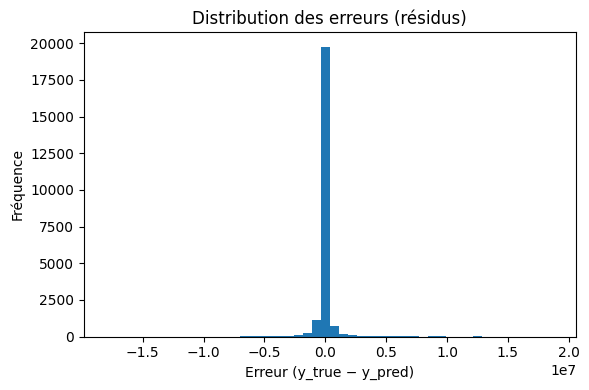

In [49]:
#Histogramme des résidus
plt.figure(figsize=(6, 4))
plt.hist(errors_df["residual"], bins=50)
plt.xlabel("Erreur (y_true − y_pred)")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs (résidus)")
plt.tight_layout()
plt.show()


In [50]:
#Erreur moyenne par département
if "department_code" in errors_df.columns:
    print("Erreur moyenne absolue par département :")
    print(
        errors_df
        .groupby("department_code")["abs_error"]
        .mean()
        .sort_values()
    )


Erreur moyenne absolue par département :
department_code
77    1.177367e+05
95    1.586576e+05
91    1.873141e+05
78    2.159103e+05
93    2.858785e+05
94    3.158961e+05
92    6.535250e+05
75    1.617344e+06
Name: abs_error, dtype: float64


In [51]:
#Erreur par tranches de surface
# Créer des classes de surface
bins = [0, 30, 60, 90, 150, np.inf]
labels = ["≤30m²", "30–60m²", "60–90m²", "90–150m²", "≥150m²"]
errors_df["surface_bin"] = pd.cut(errors_df["building_area"], bins=bins, labels=labels)

errors_df.groupby("surface_bin")["abs_pct_error"].mean().sort_index()


/tmp/ipykernel_20508/162923999.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  errors_df.groupby("surface_bin")["abs_pct_error"].mean().sort_index()


surface_bin
≤30m²                inf
30–60m²              inf
60–90m²              inf
90–150m²    1.300557e+05
≥150m²               inf
Name: abs_pct_error, dtype: float64